In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [17]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','SibSp','Parch','Survived'])

In [18]:
df

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500
...,...,...,...,...,...
886,0,27.0,0,0,13.0000
887,1,19.0,0,0,30.0000
888,0,NaN,1,2,23.4500
889,1,26.0,0,0,30.0000


In [19]:
df['Family']=df['SibSp']+df['Parch']

In [20]:
df.drop(['SibSp','Parch'],axis=1,inplace=True)

In [21]:
df


,Survived,Age,Fare,Family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0
...,...,...,...,...
886,0,27.0,13.0000,0
887,1,19.0,30.0000,0
888,0,NaN,23.4500,3
889,1,26.0,30.0000,0


In [22]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
Family      0.000000
dtype: float64

In [26]:
X=df.drop('Survived',axis=1)
Y=df['Survived']

In [27]:

X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [28]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [29]:
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()
mean_fare=X_train['Fare'].mean()
median_fare=X_train['Fare'].median()

In [30]:
X_train['Age_median']=X_train['Age'].fillna(median_age)
X_train['Age_mean']=X_train['Age'].fillna(mean_age)

X_train['Fare_median']=X_train['Fare'].fillna(median_fare)
X_train['Fare_mean']=X_train['Fare'].fillna(mean_fare)

In [32]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
155,51.0,61.3792,1,51.0,51.0,61.3792,61.3792
660,50.0,133.6500,2,50.0,50.0,133.6500,133.6500
193,3.0,26.0000,2,3.0,3.0,26.0000,26.0000
799,30.0,24.1500,2,30.0,30.0,24.1500,24.1500
715,19.0,7.6500,0,19.0,19.0,7.6500,7.6500


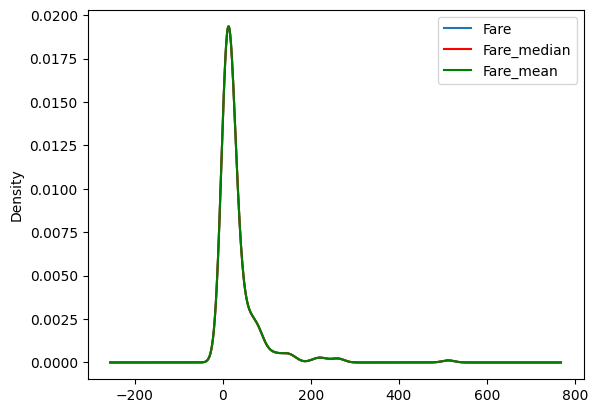

In [33]:
fig=plt.figure()
ax=fig.add_subplot(111)
# Original variable distribution
X_train['Fare'].plot(kind='kde',ax=ax)
# variable imputed with the median
X_train['Fare_median'].plot(kind='kde',ax=ax,color='red')
# variable imputed with the mean
X_train['Fare_mean'].plot(kind='kde',ax=ax,color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

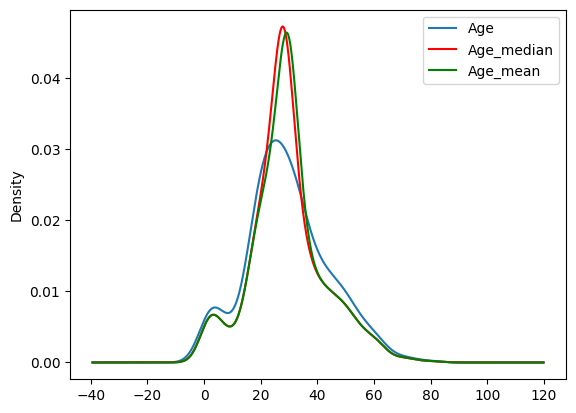

In [34]:
fig=plt.figure()
ax=fig.add_subplot(111)
# Original variable distribution
X_train['Age'].plot(kind='kde',ax=ax)
# variable imputed with the median
X_train['Age_median'].plot(kind='kde',ax=ax,color='red')
# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde',ax=ax,color='green')
# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')


In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [37]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')


In [39]:
trf=ColumnTransformer([
    ('imputer_median',imputer1,['Age']),
    ('imputer_mean',imputer2,['Fare'])
],remainder='passthrough')

In [40]:
trf.fit(X_train)


,transformers,"[('imputer_median', ...), ('imputer_mean', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [46]:
X_train=trf.transform(X_train)
X_test=trf.transform(X_test)

In [47]:
X_train

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.1083,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]])